# Notebook 3 — Machine Learning for Forecasting and Anomaly Detectioon 
## Energy Consumption Prediction — E-Redes Portugal

---

## Notebook Overview

This notebook builds and evaluates forecasting models for hourly electricity
consumption across Portuguese municipalities. We train on the feature-engineered
dataset produced in Notebook 2 and evaluate three complementary approaches:

| Model | Framework | Purpose |
|-------|-----------|--------|
| Linear Regression | Spark MLlib | Interpretable baseline |
| Gradient Boosted Trees (GBT) | Spark MLlib | Primary production model |

We use ML pipeline encapsulating every preprocessing step needed in order to prepare the dataset for 

Also since time series and as explained in notebooook 2 

### Why these three?
- **Linear Regression** establishes a minimum performance bar. If GBT doesn't
  beat it substantially, our features aren't capturing non-linear patterns.
- **GBT** is the recommended production model — it handles non-linearities,
  interactions between features (hour × is_holiday), and is natively distributed in Spark.
- **LSTM** is the state-of-the-art approach for time series. MLlib does not
  support recurrent networks natively, so we demonstrate it on a single
  municipality as a proof of concept with an explicit big-data caveat.

### Evaluation metrics
- **RMSE** (Root Mean Squared Error) — primary metric, penalises large errors heavily.
  Important for grid planning where peak demand spikes are costly to miss.
- **MAE** (Mean Absolute Error) — average error magnitude, more interpretable.
- **MAPE** (Mean Average Percentage Error) - 
- **R²** — proportion of variance explained by the model.


## Setup

---

## 1. Environment Setup

In [59]:
import sys
import os
import warnings
import itertools
warnings.filterwarnings('ignore')

import pyspark
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import DoubleType
from pyspark.ml.regression import GBTRegressor


# MLlib — Pipeline and feature engineering
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import (
    VectorAssembler, StandardScaler,
    StringIndexer, OneHotEncoder
)

# MLlib — Models
from pyspark.ml.regression import (
    LinearRegression,
    RandomForestRegressor,
    GBTRegressor
)

# MLlib — Evaluation and tuning
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
sys.path.append('/home/jovyan/code/utils')


import pandas as pd
from feature_eng import (
    TemporalFeatureTransformer,
    HolidayFlagTransformer,
    LagFeatureTransformer,
    NullLagDropTransformer
)

from evaluation import (
    evaluate_model, 
    evaluate_by_municipality, 
    compare_models
)


# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"]    = 100

sys.path.append('/home/jovyan/code/utils')

PLOT_DIR = "code/plots/"
os.makedirs(PLOT_DIR, exist_ok=True)

print(f"PySpark version: {pyspark.__version__}")
print(f"Python:          {sys.version.split('|')[0].strip()}")

PySpark version: 3.5.0
Python:          3.11.6


In [60]:
spark = (
    SparkSession.builder
    .appName("bda_eredes_modelling")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", 6)
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .getOrCreate()
)

spark

In [61]:
DATA_DIR         = "code/data/"
MODEL_INPUT      = DATA_DIR + "model_input/model_input.parquet"
MODEL_OUTPUT_DIR = DATA_DIR + "models/"

os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)

TARGET_COL = "total_active_energy_kwh"

---
## 2. Load & Inspect Model Input Data

In [62]:
df = spark.read.parquet(MODEL_INPUT)
df.createOrReplaceTempView("eredes")

print(f"Total rows:    {df.count():,}")
print(f"Total columns: {len(df.columns)}")
print("\nSchema:")
df.printSchema()

print("\nSample:")
df.cache()
df.show(3, truncate=False)

Total rows:    2,228,170
Total columns: 4

Schema:
root
 |-- municipality: string (nullable = true)
 |-- datetime: timestamp (nullable = true)
 |-- total_active_energy_kwh: double (nullable = true)
 |-- year_month: string (nullable = true)


Sample:
+------------+-------------------+-----------------------+----------+
|municipality|datetime           |total_active_energy_kwh|year_month|
+------------+-------------------+-----------------------+----------+
|peniche     |2022-12-01 00:00:00|9723.999598886292      |2022-12   |
|nelas       |2022-12-01 00:00:00|23449.73224200879      |2022-12   |
|torres novas|2022-12-01 01:00:00|19766.59265957604      |2022-12   |
+------------+-------------------+-----------------------+----------+
only showing top 3 rows



---
## 3. Train / Test Split

For time series data, a **temporal split** is mandatory — we cannot use
random splitting. Random splitting would allow the model to train on
future data (e.g. February) and predict past data (e.g. January),
which constitutes **data leakage** and produces optimistically biased metrics.

We use the last 7 days of the series as the test set, everything before as training.

In [63]:
# Temporal train/test split.

# We find the cutoff date (max date minus 7 days) and split there.
# This guarantees the model never sees future data during training.

# Temporal split — no random splitting for time series
max_date  = df.agg(F.max("datetime")).first()[0]
cutoff    = max_date - pd.Timedelta(days=7)
context_cutoff = cutoff - pd.Timedelta(days=7)

train_df  = df.filter(F.col("datetime") <= cutoff)
test_df   = df.filter(F.col("datetime") >  cutoff)

# Context window: last 168 hours of training data
# Used by LagFeatureTransformer when transforming the test set
context_df = train_df.filter(F.col("datetime") >= context_cutoff)
train_count = train_df.count()
test_count  = test_df.count()
total       = train_count + test_count

print(f"Training set:  {train_count:,} rows  ({train_count/total*100:.1f}%)")
print(f"Test set:      {test_count:,} rows  ({test_count/total*100:.1f}%)")
print(f"Train up to:   {cutoff}")
print(f"Test from:     {cutoff}  →  {max_date}")

Training set:  2,181,466 rows  (97.9%)
Test set:      46,704 rows  (2.1%)
Train up to:   2023-09-23 22:00:00
Test from:     2023-09-23 22:00:00  →  2023-09-30 22:00:00


---
## 4. Feature Encoding & Normalisation Pipeline

We now prepare the ML-ready feature vector. This section applies:

- **OneHotEncoder** for ordinal categorical features (`hour_of_day`, `day_of_week`, `month`)
- **VectorAssembler** to combine all features into a single vector column
- **StandardScaler** for Linear Regression (scale-sensitive)

These steps are intentionally separated from the feature engineering in
Notebook 2: encoding only exists to feed the algorithm, not to aid understanding.

In [65]:

def build_pipeline(model, context_df=None):
    """
    Assembles the full feature engineering + encoding + model pipeline.

    Parameters
    ----------
    model      : unfitted MLlib Estimator (LR, GBT, RandomForest, etc.)
    context_df : optional tail of training data for test-set lag computation.
                 Pass None during training, pass training tail during inference.

    Returns
    -------
    Spark ML Pipeline — call .fit(train_df) to train.
    """

    # Feature engineering 
    temporal  = TemporalFeatureTransformer()
    holiday   = HolidayFlagTransformer()
    lag       = LagFeatureTransformer(context_df=context_df)
    null_drop = NullLagDropTransformer()

    # ── Categorical encoding ─────────────────────────────────────────────────
    categorical_cols = ["hour_of_day", "day_of_week", "month"]
    indexed_cols     = [f"{c}_idx" for c in categorical_cols]
    encoded_cols     = [f"{c}_ohe" for c in categorical_cols]

    indexers = [
        StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
        for c in categorical_cols
    ]

    encoder = OneHotEncoder(
        inputCols=indexed_cols,
        outputCols=encoded_cols,
        handleInvalid="keep"
    )

    # ── Feature assembly ─────────────────────────────────────────────────────
    continuous_cols = [
        "is_weekend", "is_holiday", "day_of_month",
         "lag_168h"
    ]

    assembler = VectorAssembler(
        inputCols=encoded_cols + continuous_cols,
        outputCol="features_raw",
        handleInvalid="skip"
    )

    scaler = StandardScaler(
        inputCol="features_raw",
        outputCol="features",
        withMean=True,
        withStd=True
    )

    # ── Full pipeline ────────────────────────────────────────────────────────
    stages = (
        [temporal, holiday, lag, null_drop]    # feature engineering
        + indexers                              # index categoricals
        + [encoder, assembler, scaler, model]   # encode + assemble + model
    )

    return Pipeline(stages=stages)

In [66]:
def run_time_series_cv(df, pipeline_func, model_estimator, max_date_str, n_folds=3):
    """
    Executes a rolling-origin time-series cross-validation.
    Each validation fold is exactly 7 days long.
    """
    max_date = pd.to_datetime(max_date_str)
    fold_metrics = []
    
    print(f"Starting {n_folds}-Fold Time-Series Cross-Validation...")
    print(f"Global Data End Point: {max_date}")
    print("-" * 60)
    
    for fold in range(n_folds):
        # 1. Dynamically calculate boundaries for this specific fold
        # Fold 0 validates the last week, Fold 1 validates the week before that, etc.
        val_end_date = max_date - pd.Timedelta(days=7 * fold)
        val_start_date = val_end_date - pd.Timedelta(days=7)
        train_cutoff = val_start_date
        
        # Context window for lag calculation must be the 7 days directly preceding the validation split
        context_start_date = train_cutoff - pd.Timedelta(days=7)
        
        print(f"--- FOLD {fold + 1} ---")
        print(f"  Training Data Ends : {train_cutoff}")
        print(f"  Validation Horizon : {val_start_date} to {val_end_date}")
        
        # 2. Slice the datasets programmatically
        fold_train = df.filter(F.col("datetime") < train_cutoff)
        fold_context = df.filter((F.col("datetime") >= context_start_date) & (F.col("datetime") < train_cutoff))
        fold_val = df.filter((F.col("datetime") >= val_start_date) & (F.col("datetime") < val_end_date))
        
        # 3. Instantiate and Fit the training pipeline for this fold
        fold_pipeline = pipeline_func(model=model_estimator, context_df=None)
        fitted_fold_model = fold_pipeline.fit(fold_train)
        
        # 4. Prepare Validation Set with its proper context window
        val_with_context = fold_context.unionByName(fold_val)
        val_preds = fitted_fold_model.transform(val_with_context)
        
        # Cleanly slice back down to the validation week rows only
        final_val_eval = val_preds.filter((F.col("datetime") >= val_start_date) & (F.col("datetime") < val_end_date))
        
        # 5. Evaluate this fold's performance (using native evaluators)
        evaluator = RegressionEvaluator(labelCol=TARGET_COL, predictionCol="prediction")
        
        rmse = evaluator.setMetricName("rmse").evaluate(final_val_eval)
        mae  = evaluator.setMetricName("mae").evaluate(final_val_eval)
        r2   = evaluator.setMetricName("r2").evaluate(final_val_eval)
        
        fold_metrics.append({"fold": fold + 1, "rmse": rmse, "mae": mae, "r2": r2})
        print(f"  Result -> RMSE: {rmse:,.2f} | MAE: {mae:,.2f} | R²: {r2:.4f}\n")
        
    # 6. Aggregate results across all folds
    cv_results_df = pd.DataFrame(fold_metrics)
    print("=" * 60)
    print("FINISHED CROSS-VALIDATION SUMMARY")
    print("=" * 60)
    print(f"Mean CV RMSE : {cv_results_df['rmse'].mean():,.2f} kWh")
    print(f"Mean CV MAE  : {cv_results_df['mae'].mean():,.2f} kWh")
    print(f"Mean CV R²   : {cv_results_df['r2'].mean():.4f}")
    print("=" * 60)
    
    return cv_results_df

---
## 5. Model 1 — Linear Regression (Baseline)

Linear Regression is our baseline. It assumes a linear relationship between
features and consumption — clearly a simplification, but it sets the minimum
bar that more complex models must beat to justify their added complexity.

In [67]:
# ---------------------------------------------------------------------------
# Linear Regression pipeline.
#
# StandardScaler is essential here — linear regression is sensitive to
# feature scale. Without scaling, lag_1h (~15,000 kWh range) would dominate
# the gradient updates over is_holiday (0/1 range).
#
# We fit two pipeline instances:
#   1. context_df=None  → training (full history already in train_df)
#   2. context_df=...   → test inference (context prepended for boundary rows)
#
# Both are fitted on train_df only — context_df only affects the
# LagFeatureTransformer, not the model weights.
# ---------------------------------------------------------------------------

print("Training Linear Regression...")

lr = LinearRegression(
    featuresCol="features",
    labelCol=TARGET_COL,
    maxIter=100,
    regParam=0.1,      # L2 regularisation — prevents overfitting
    elasticNetParam=0  # 0 = Ridge, 1 = Lasso, in-between = ElasticNet
)

# Fit and transform training set
# 1. Build and Fit the pipeline EXACTLY ONCE on the raw training data
# At this stage, context_df=None because training data has its own history.
lr_pipeline = build_pipeline(model=lr, context_df=None)
fitted_pipeline_model = lr_pipeline.fit(train_df)

# 2. Get your training predictions safely
gbt_train_preds = fitted_pipeline_model.transform(train_df)

# 3. Prepare the Test Data with its historical context window
# Instead of modifying the pipeline structure, append context tail directly 
# to the test dataframe before feeding it into the already-fitted pipeline
test_with_context_df = context_df.unionByName(test_df)

# 4. Transform using fitted model weights
# This ensures StringIndexer, OHE, Scaler, and GBT use identical parameters.
combined_test_preds = fitted_pipeline_model.transform(test_with_context_df)

# 5. Clean up the context rows so you only evaluate the actual Test Set horizon
# Since NullLagDropTransformer or lags might create boundary constraints,
# filter back down to your strict test time window.
gbt_test_preds = combined_test_preds.filter(F.col("datetime") >= "2023-09-24")

print("✓ Done")

# Evaluate 
print("\n── Training set performance ──")
gbt_train_metrics = evaluate_model(gbt_train_preds, TARGET_COL, "Gradient Boosted Trees (Train)")

print("\n── Test set performance ──")
gbt_test_metrics  = evaluate_model(gbt_test_preds,  TARGET_COL, "Gradient Boosted Trees (Test)")


Training Linear Regression...
✓ Done

── Training set performance ──
RMSE: 4,978.30
MAE:  1,838.93
R2:   0.9730
MAPE: 61.97%

── Test set performance ──
RMSE: 4,877.92
MAE:  1,760.88
R2:   0.9743
MAPE: 523.10%



  Per-Municipality Evaluation — Linear Regression
  Municipalities evaluated : 278
  Median RMSE              : 1,333.25 kWh
  Median MAPE              : 16.57%
  Worst municipality (RMSE): seixal  (45,418.48 kWh)
  Best  municipality (RMSE): vendas novas  (634.41 kWh)

          municipality  n_rows     rmse      mae  mape  mean_actual  mean_predicted  mean_bias    r2
                seixal     167 45418.48 31365.29 28.23    122791.83       117117.48   -5674.35 -0.44
                lisboa     167 32421.16 23315.74  7.25    313914.92       306197.44   -7717.48  0.83
                  maia     167 19524.92 13481.58  9.27    151249.00       148856.69   -2392.32  0.39
  santa maria da feira     167 19180.84 12025.78 18.82     73597.87        72368.22   -1229.65  0.20
vila nova de famalicão     167 17197.89 10761.72 12.19     96146.68        94349.91   -1796.76  0.14
             guimarães     167 16545.58 10189.46 17.80     66244.37        64834.59   -1409.78  0.28
       figueira da fo

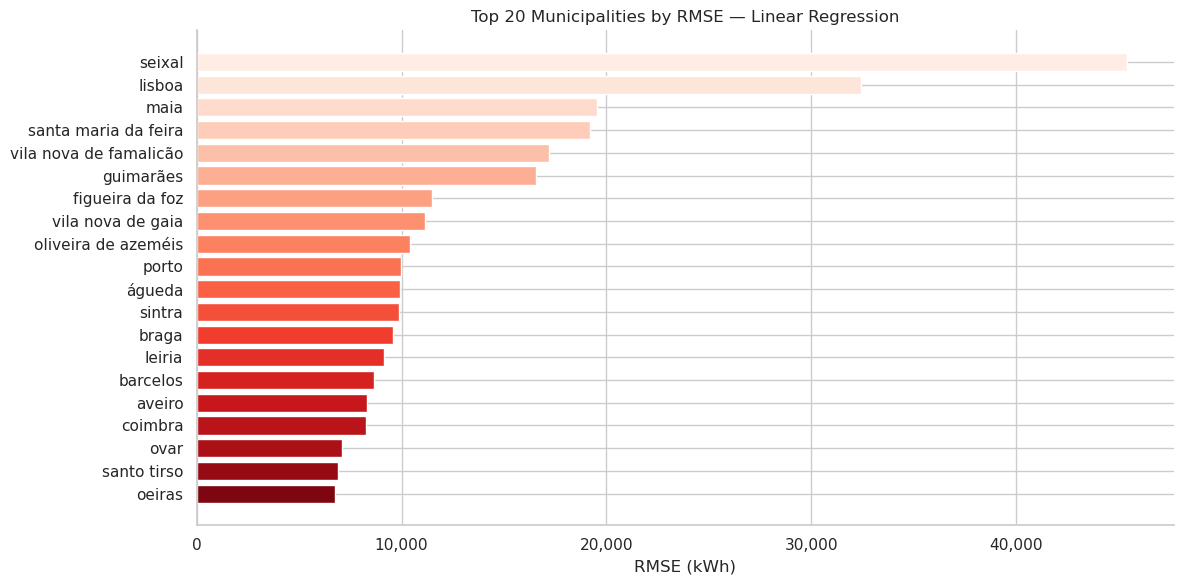

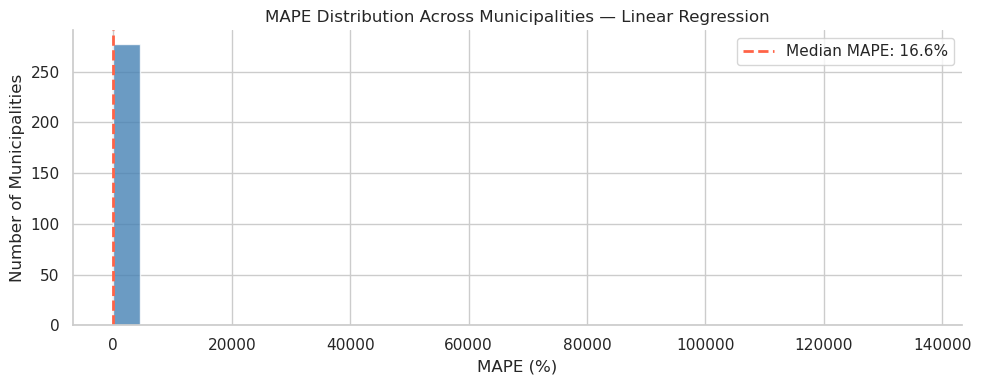

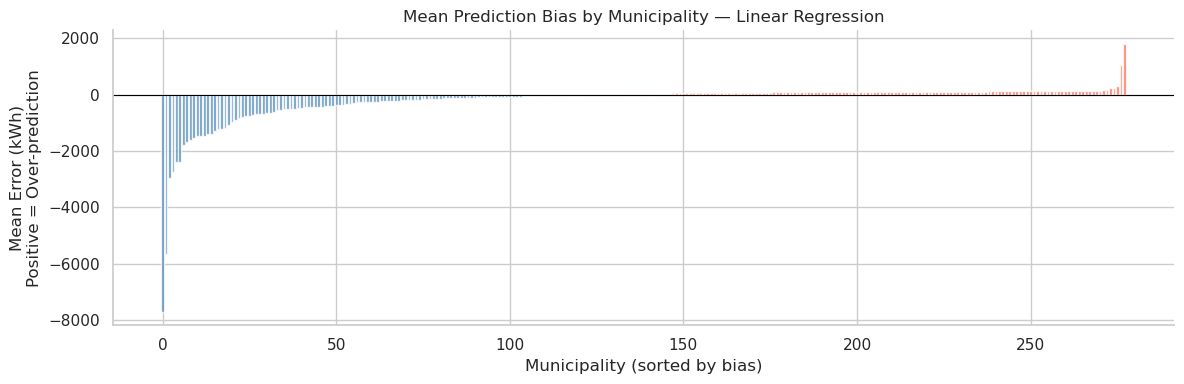

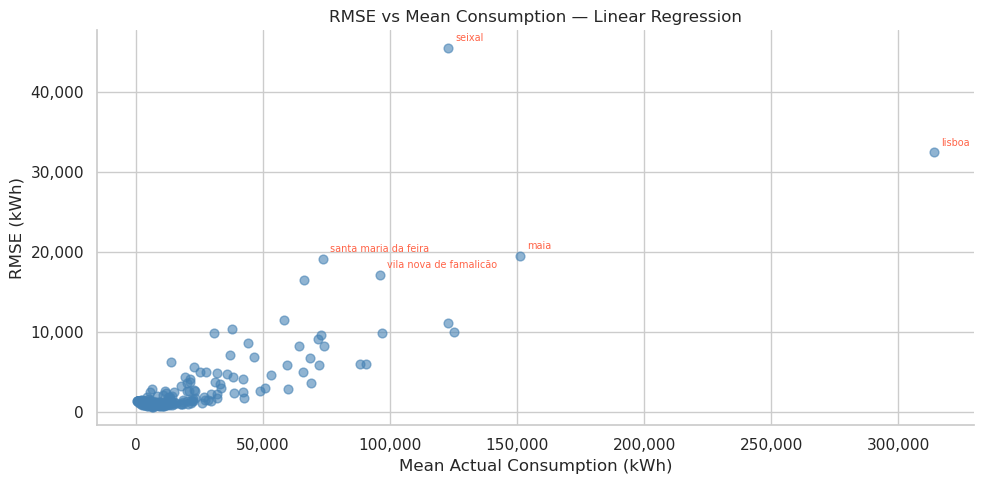

In [68]:
lr_munic  = evaluate_by_municipality(gbt_test_preds,  TARGET_COL, "Linear Regression", plot=True)

In [69]:
# Run it for your Linear Regression Model
lr_cv_results = run_time_series_cv(
    df=df,
    pipeline_func=build_pipeline,
    model_estimator=lr,
    max_date_str=max_date,
    n_folds=5
)

Starting 5-Fold Time-Series Cross-Validation...
Global Data End Point: 2023-09-30 22:00:00
------------------------------------------------------------
--- FOLD 1 ---
  Training Data Ends : 2023-09-23 22:00:00
  Validation Horizon : 2023-09-23 22:00:00 to 2023-09-30 22:00:00
  Result -> RMSE: 4,825.13 | MAE: 1,752.19 | R²: 0.9748

--- FOLD 2 ---
  Training Data Ends : 2023-09-16 22:00:00
  Validation Horizon : 2023-09-16 22:00:00 to 2023-09-23 22:00:00
  Result -> RMSE: 4,549.42 | MAE: 1,718.84 | R²: 0.9768

--- FOLD 3 ---
  Training Data Ends : 2023-09-09 22:00:00
  Validation Horizon : 2023-09-09 22:00:00 to 2023-09-16 22:00:00
  Result -> RMSE: 4,639.88 | MAE: 1,713.85 | R²: 0.9769

--- FOLD 4 ---
  Training Data Ends : 2023-09-02 22:00:00
  Validation Horizon : 2023-09-02 22:00:00 to 2023-09-09 22:00:00
  Result -> RMSE: 4,693.38 | MAE: 1,729.96 | R²: 0.9759

--- FOLD 5 ---
  Training Data Ends : 2023-08-26 22:00:00
  Validation Horizon : 2023-08-26 22:00:00 to 2023-09-02 22:00:00


---
## 6. Model 2 — Gradient Boosted Trees

GBT builds an ensemble of decision trees sequentially, each correcting the
errors of the previous. It excels at capturing non-linear relationships and
feature interactions — for example, the interaction between `hour_of_day` and
`is_holiday` (a holiday at 09:00 behaves very differently from a weekday at 09:00).

GBT is our recommended production model: fully distributed in Spark,
no feature scaling required, and provides feature importance out of the box.

In [70]:
print("Training GBTRegressor...")

gbt = GBTRegressor(
    featuresCol="features",
    labelCol=TARGET_COL,
    maxIter=20,         # number of trees
    maxDepth=5,          # depth per tree — deeper = more complex, more overfit risk
    stepSize=0.1,        # learning rate
    subsamplingRate=0.8, # row subsampling — reduces overfitting
    seed=42
)
# Fit and transform training set
# 1. Build and Fit the pipeline EXACTLY ONCE on the raw training data
# At this stage, context_df=None because training data has its own history.
gbt_pipeline = build_pipeline(model=gbt, context_df=None)
fitted_pipeline_model = gbt_pipeline.fit(train_df)

# 2. Get your training predictions safely
gbt_train_preds = fitted_pipeline_model.transform(train_df)

# 3. Prepare the Test Data with its historical context window
# Instead of modifying the pipeline structure, append context tail directly 
# to the test dataframe before feeding it into the already-fitted pipeline
test_with_context_df = context_df.unionByName(test_df)

# 4. Transform using the fitted model weights
# This ensures StringIndexer, OHE, Scaler, and GBT use identical parameters.
combined_test_preds = fitted_pipeline_model.transform(test_with_context_df)

# 5. Clean up the context rows so you only evaluate the actual Test Set horizon
# Since NullLagDropTransformer or lags might create boundary constraints,
# filter back down to your strict test time window.
gbt_test_preds = combined_test_preds.filter(F.col("datetime") >= "2023-09-24")

print("Done")

# ── Evaluate ─────────────────────────────────────────────────────────────────
print("\n── Training set performance ──")
gbt_train_metrics = evaluate_model(gbt_train_preds, TARGET_COL, "Gradient Boosted Trees (Train)")

print("\n── Test set performance ──")
gbt_test_metrics  = evaluate_model(gbt_test_preds,  TARGET_COL, "Gradient Boosted Trees (Test)")

Training GBTRegressor...
Done

── Training set performance ──
RMSE: 9,633.54
MAE:  2,481.90
R2:   0.8990
MAPE: 57.57%

── Test set performance ──
RMSE: 10,141.50
MAE:  2,458.07
R2:   0.8887
MAPE: 314.60%



  Per-Municipality Evaluation — Gradient Boosted Trees
  Municipalities evaluated : 278
  Median RMSE              : 804.75 kWh
  Median MAPE              : 12.27%
  Worst municipality (RMSE): lisboa  (123,202.20 kWh)
  Best  municipality (RMSE): arronches  (147.30 kWh)

          municipality  n_rows      rmse       mae  mape  mean_actual  mean_predicted  mean_bias    r2
                lisboa     167 123202.20 101221.67 28.50    313914.92       215966.07  -97948.85 -1.42
                seixal     167  70707.08  58779.19 50.22    122791.83       134374.55   11582.72 -2.49
                  maia     167  47844.13  42469.44 28.06    151249.00       164969.35   13720.35 -2.66
                 porto     167  38557.30  31913.56 23.20    125190.08       134968.32    9778.24 -0.61
     vila nova de gaia     167  34568.26  27933.49 20.79    122926.37       116431.47   -6494.90 -1.02
  santa maria da feira     167  16634.11  12336.75 18.73     73597.87        75441.96    1844.09  0.40
      

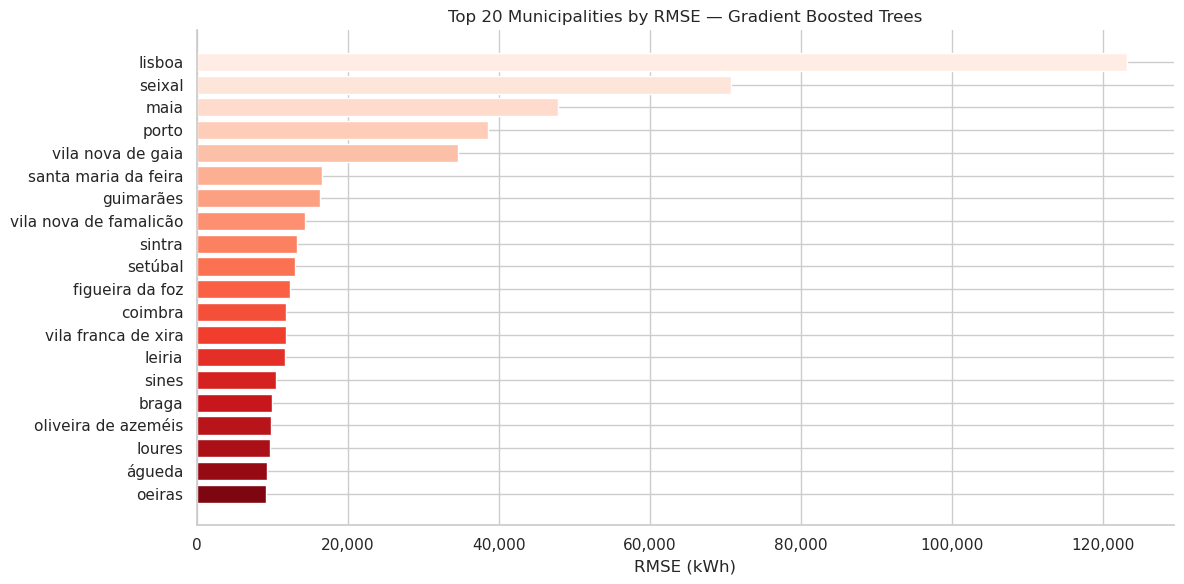

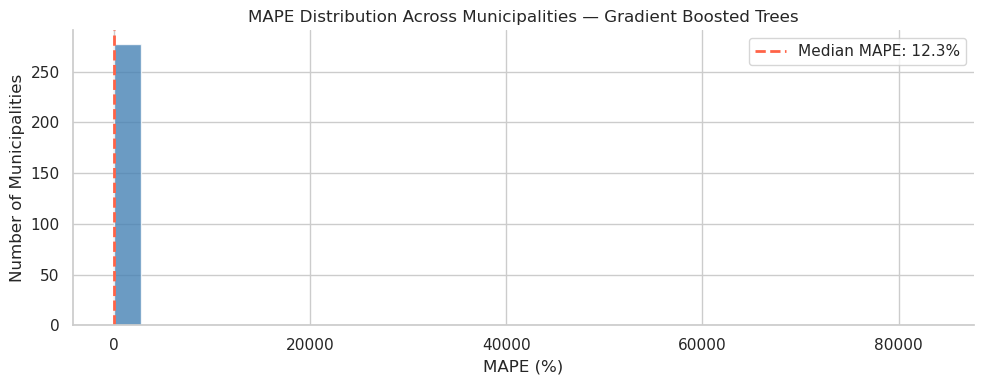

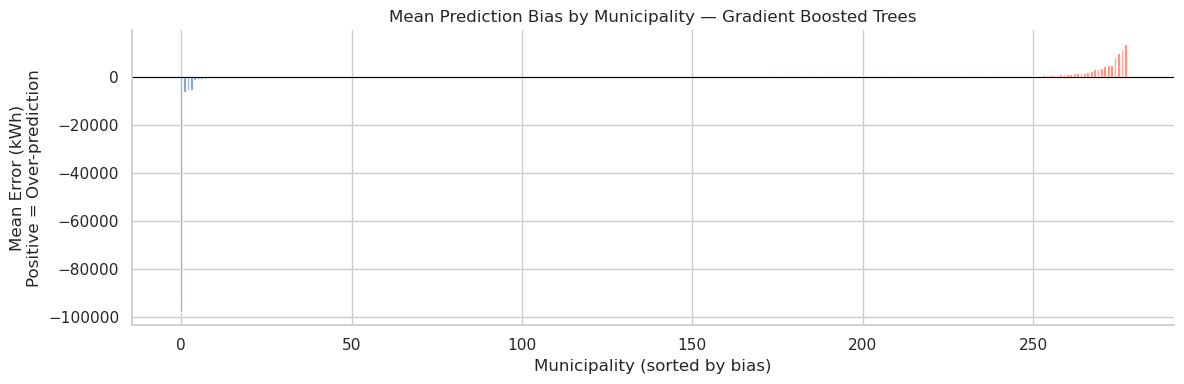

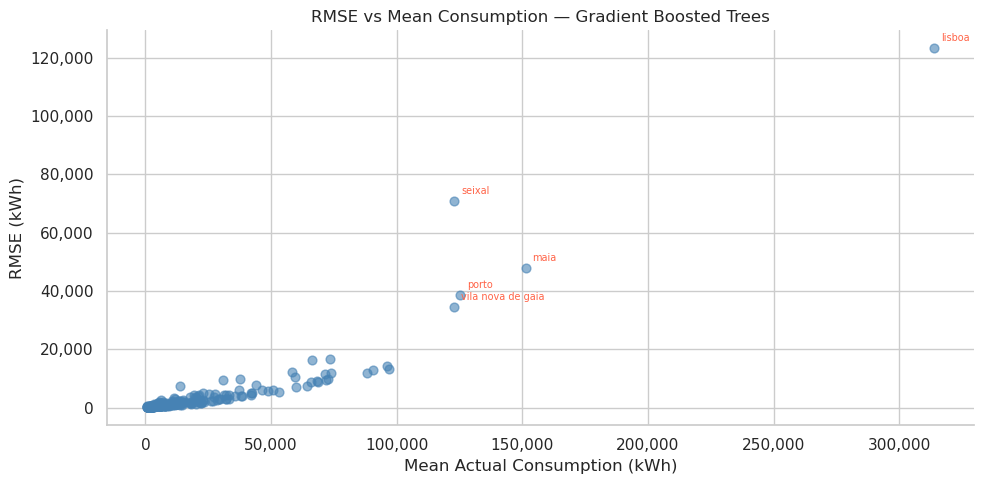

In [71]:
gbt_metrics = evaluate_by_municipality(gbt_test_preds, TARGET_COL, "Gradient Boosted Trees")

In [72]:
# ---------------------------------------------------------------------------
# Hyperparameter tuning via CrossValidator.
#
# We tune two key GBT hyperparameters:
#   maxDepth    — controls tree complexity (bias-variance tradeoff)
#   maxIter     — number of boosting rounds
#
# CrossValidator uses k-fold cross-validation. For time series, standard
# k-fold is not strictly correct (it can leak future data into earlier folds).
#
# For time series data, TimeSeriesSplit (walk-forward validation) is more
# appropriate as it preserves temporal order. MLlib does not natively support
# TimeSeriesSplit


# 1. Define your tuning search space parameters
gbt_param_grid = {
    "maxDepth": [4, 6],
    "maxIter": [20, 40]
}

# 2. Programmatically unpack the grid into individual experiment dictionaries
keys, values = zip(*gbt_param_grid.items())
experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]

# Trackers for the grid leaderboard
best_rmse = float('inf')
best_params = None
all_grid_records = []


print(f"Initializing Grid Search Loop: {len(experiments)} configurations...")
print("=" * 75)

# 3. Iterate over the parameter configurations and call function directly
for i, params in enumerate(experiments):
    print(f"\n [GRID STEP {i+1}/{len(experiments)}] Testing Configuration: {params}")
    print("=" * 75)
    
    # Dynamically initialize the estimator with the grid's parameter states
    gbt_estimator = GBTRegressor(
        featuresCol="features",
        labelCol=TARGET_COL,
        seed=42,
        **params
    )
    
    # cv function
    cv_results = run_time_series_cv(
        df=df,
        pipeline_func=build_pipeline,
        model_estimator=gbt_estimator, 
        max_date_str=max_date,
        n_folds=3                    
    )
    
    # Extract the mean performance metrics 
    mean_rmse = cv_results['rmse'].mean()
    mean_mae  = cv_results['mae'].mean()
    mean_r2   = cv_results['r2'].mean()
    
    # Save statistics for summary logging
    record = params.copy()
    record["mean_rmse"] = mean_rmse
    record["mean_mae"] = mean_mae
    record["mean_r2"] = mean_r2
    all_grid_records.append(record)
    
    # Check if this configuration wins the leaderboard
    if mean_rmse < best_rmse:
        best_rmse = mean_rmse
        best_params = params

# 4. Print the final leaderboard results
print("\n" + "=" * 75)
print(" HYPERPARAMETER GRID SEARCH METRIC SUMMARY")
print("=" * 75)
print(f"Winner Configuration : {best_params}")
print(f"Top Mean CV RMSE     : {best_rmse:,.2f} kWh")
print("=" * 75)

# Convert the history log to a Pandas DataFrame for your viewing
grid_leaderboard_df = pd.DataFrame(all_grid_records).sort_values(by="mean_rmse")

Initializing Grid Search Loop: 4 configurations...

 [GRID STEP 1/4] Testing Configuration: {'maxDepth': 4, 'maxIter': 20}
Starting 5-Fold Time-Series Cross-Validation...
Global Data End Point: 2023-09-30 22:00:00
------------------------------------------------------------
--- FOLD 1 ---
  Training Data Ends : 2023-09-23 22:00:00
  Validation Horizon : 2023-09-23 22:00:00 to 2023-09-30 22:00:00
  Result -> RMSE: 10,327.32 | MAE: 2,504.71 | R²: 0.8844

--- FOLD 2 ---
  Training Data Ends : 2023-09-16 22:00:00
  Validation Horizon : 2023-09-16 22:00:00 to 2023-09-23 22:00:00
  Result -> RMSE: 9,143.89 | MAE: 2,484.98 | R²: 0.9063

--- FOLD 3 ---
  Training Data Ends : 2023-09-09 22:00:00
  Validation Horizon : 2023-09-09 22:00:00 to 2023-09-16 22:00:00
  Result -> RMSE: 9,911.55 | MAE: 2,496.16 | R²: 0.8946

--- FOLD 4 ---
  Training Data Ends : 2023-09-02 22:00:00
  Validation Horizon : 2023-09-02 22:00:00 to 2023-09-09 22:00:00
  Result -> RMSE: 9,520.48 | MAE: 2,508.33 | R²: 0.9008



ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/usr/local/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/clientserver.py", line 511, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/socket.py", line 706, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt


KeyboardInterrupt: 

In [ ]:
# Extract feature names from the VectorAssembler metadata.
#
# When OneHotEncoder is used, each categorical column expands into multiple
# binary slots in the feature vector. assembler.getInputCols() returns the
# pre-OHE column names (e.g. "hour_of_day_ohe") not the individual slot
# names (e.g. "hour_of_day_0", "hour_of_day_1", ...).
#
# The correct approach is to read the feature metadata from the transformed
# DataFrame schema, which Spark populates with the actual slot names after
# OHE expansion.

def extract_feature_names(pipeline_model, transformed_df, features_col="features_raw"):
    """
    Extracts the true feature names from the VectorAssembler output metadata,
    correctly handling OneHotEncoded columns which expand into multiple slots.

    Parameters
    ----------
    pipeline_model  : fitted PipelineModel
    transformed_df  : DataFrame output from pipeline_model.transform()
    features_col    : name of the assembled feature vector column

    Returns
    -------
    list of feature name strings matching the feature vector indices
    """
    feature_names = []

    # Get metadata from the schema of the assembled features column
    attrs = (
        transformed_df.schema[features_col]
        .metadata
        .get("ml_attr", {})
        .get("attrs", {})
    )

    # Nominal = OHE binary slots
    if "nominal" in attrs:
        feature_names.extend([attr["name"] for attr in attrs["nominal"]])

    # Numeric = continuous features
    if "numeric" in attrs:
        feature_names.extend([attr["name"] for attr in attrs["numeric"]])

    # Binary = binary flags (is_weekend, is_holiday)
    if "binary" in attrs:
        feature_names.extend([attr["name"] for attr in attrs["binary"]])

    # Sort by index to match the feature vector order
    all_attrs = (
        attrs.get("nominal", []) +
        attrs.get("numeric", []) +
        attrs.get("binary",  [])
    )
    all_attrs_sorted = sorted(all_attrs, key=lambda x: x["idx"])
    feature_names    = [attr["name"] for attr in all_attrs_sorted]

    return feature_names


# Feature Impoortance 

In [ ]:
df.unpersist()